# Stress Detection from Text Using NLP

A machine learning project that classifies text as **Stress** or **No Stress** using Natural Language Processing and machine learning.

### Approach
- Text preprocessing
- TF-IDF feature extraction
- Bernoulli Naive Bayes
- Logistic Regression
- Linear SVM
- Model evaluation and comparison
- User text prediction

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kavit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Load Dataset

In [44]:
data = pd.read_csv("C:\\Users\\kavit\\OneDrive\\Desktop\\projects\\Stress_Detection_NLP\\data\\stress.csv")

print("Dataset loaded successfully!")
print("Shape:", data.shape)

Dataset loaded successfully!
Shape: (2838, 116)


## 3. Dataset Overview
The dataset contains 2,838 text samples and 116 features. The target variable `label` represents whether a sample is classified as stress or no stress.

In [45]:
data.head()

,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.6,1516429555,0,2.667798,...,1.000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.8,1539809005,24,7.554238,...,1.000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167


In [46]:
data.columns

Index(['subreddit', 'post_id', 'sentence_range', 'text', 'id', 'label',
       'confidence', 'social_timestamp', 'social_karma', 'syntax_ari',
       ...
       'lex_dal_min_pleasantness', 'lex_dal_min_activation',
       'lex_dal_min_imagery', 'lex_dal_avg_activation', 'lex_dal_avg_imagery',
       'lex_dal_avg_pleasantness', 'social_upvote_ratio',
       'social_num_comments', 'syntax_fk_grade', 'sentiment'],
      dtype='str', length=116)

In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2838 entries, 0 to 2837
Columns: 116 entries, subreddit to sentiment
dtypes: float64(106), int64(6), str(4)
memory usage: 2.5 MB


In [48]:
data.isnull().sum()

subreddit                   0
post_id                     0
sentence_range              0
text                        0
id                          0
                           ..
lex_dal_avg_pleasantness    0
social_upvote_ratio         0
social_num_comments         0
syntax_fk_grade             0
sentiment                   0
Length: 116, dtype: int64

In [49]:
data['label'].value_counts()

label
1    1488
0    1350
Name: count, dtype: int64

In [50]:
data['label'].value_counts(normalize=True) * 100

label
1    52.43129
0    47.56871
Name: proportion, dtype: float64

In [11]:
label_counts = data["label"].value_counts()

print("Class Distribution:")
print(label_counts)

print("\nClass Percentage:")
print((label_counts / len(data) * 100).round(2))

Class Distribution:
label
1    1488
0    1350
Name: count, dtype: int64

Class Percentage:
label
1    52.43
0    47.57
Name: count, dtype: float64


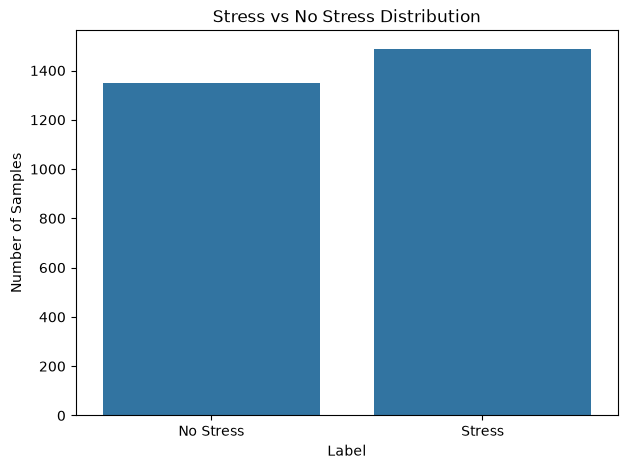

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(data=data, x="label")

plt.title("Stress vs No Stress Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["No Stress", "Stress"])

plt.show()

In [13]:
data["text_length"] = data["text"].astype(str).apply(len)

print(data["text_length"].describe())

count    2838.000000
mean      447.996476
std       168.929122
min         6.000000
25%       339.000000
50%       421.000000
75%       528.750000
max      1639.000000
Name: text_length, dtype: float64


C:\Users\kavit\AppData\Local\Temp\ipykernel_12576\3352182754.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["text_length"] = data["text"].astype(str).apply(len)


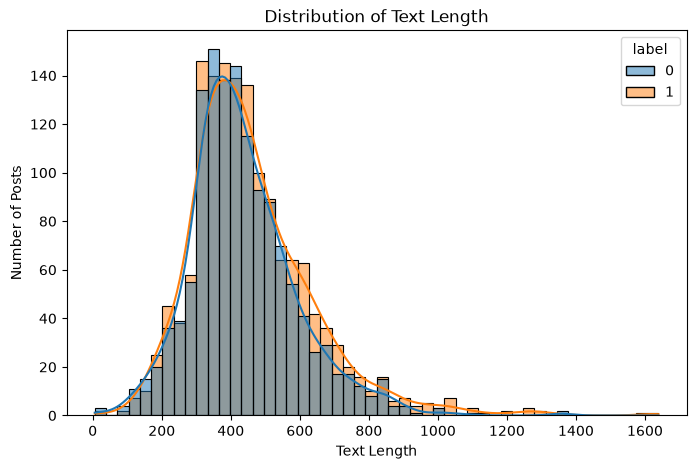

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x="text_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Number of Posts")

plt.show()

In [15]:
data.groupby("label")["text_length"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
label,,,,,
0,1350,435.100741,413.5,6,1358
1,1488,459.696237,427.5,6,1639


In [16]:
data[["text", "label"]].head(10)

,text,label
0,"He said he had not felt that way before, sugge...",1
1,"Hey there r/assistance, Not sure if this is th...",0
2,My mom then hit me with the newspaper and it s...,1
3,"until i met my new boyfriend, he is amazing, h...",1
4,October is Domestic Violence Awareness Month a...,1
5,I think he doesn't want to put in the effort f...,1
6,It was a big company so luckily I didn't have ...,0
7,It cleared up and I was okay but. On Monday ...,1
8,I actually give an assistant half my emergency...,1
9,I just feel like the street life has fucked my...,1


In [17]:
data[data["label"] == 1]["text"].head(5)

0    He said he had not felt that way before, sugge...
2    My mom then hit me with the newspaper and it s...
3    until i met my new boyfriend, he is amazing, h...
4    October is Domestic Violence Awareness Month a...
5    I think he doesn't want to put in the effort f...
Name: text, dtype: str

In [18]:
data[data["label"] == 0]["text"].head(5)

1     Hey there r/assistance, Not sure if this is th...
6     It was a big company so luckily I didn't have ...
18    This is helping to get kids in the area tan ab...
19    We had plans to move in together, a fancy $1,8...
21    I was going through a hard time after our brea...
Name: text, dtype: str

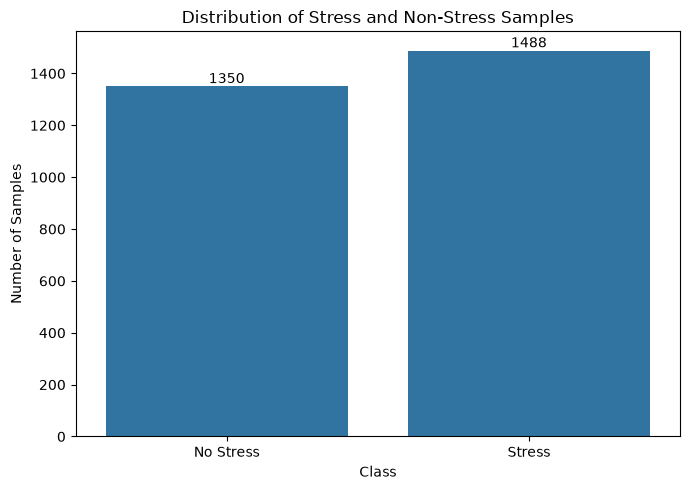

In [19]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=data, x="label")

plt.title("Distribution of Stress and Non-Stress Samples")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["No Stress", "Stress"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

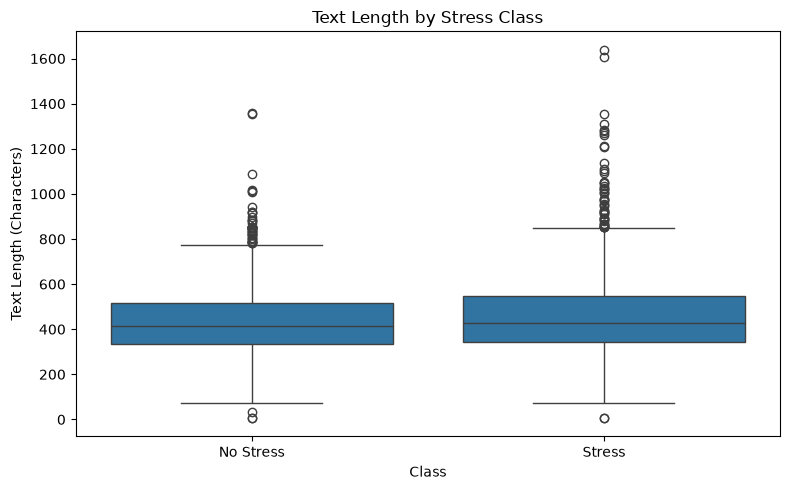

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="label",
    y="text_length"
)

plt.title("Text Length by Stress Class")
plt.xlabel("Class")
plt.ylabel("Text Length (Characters)")
plt.xticks([0, 1], ["No Stress", "Stress"])

plt.tight_layout()
plt.show()

In [21]:
data["label"] = data["label"].map({
    0: "No Stress",
    1: "Stress"
})

data = data[["text", "label"]]

data.head()

,text,label
0,"He said he had not felt that way before, sugge...",Stress
1,"Hey there r/assistance, Not sure if this is th...",No Stress
2,My mom then hit me with the newspaper and it s...,Stress
3,"until i met my new boyfriend, he is amazing, h...",Stress
4,October is Domestic Violence Awareness Month a...,Stress


## 4. Text Preprocessing

The text is cleaned by:
- Converting text to lowercase
- Removing URLs and HTML tags
- Removing punctuation and numbers
- Removing stopwords
- Applying stemming

In [22]:
stemmer = SnowballStemmer("english")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    # Remove stopwords
    words = [
        word for word in text.split()
        if word not in stop_words
    ]
    
    # Stemming
    words = [stemmer.stem(word) for word in words]
    
    return " ".join(words)

In [23]:
data["text"] = data["text"].apply(clean_text)

In [24]:
data.head()

,text,label
0,said felt way sugget go rest trigger ahead you...,Stress
1,hey rassist sure right place post goe im curre...,No Stress
2,mom hit newspap shock would know dont like pla...,Stress
3,met new boyfriend amaz kind sweet good student...,Stress
4,octob domest violenc awar month domest violenc...,Stress


## 5. Text Visualization


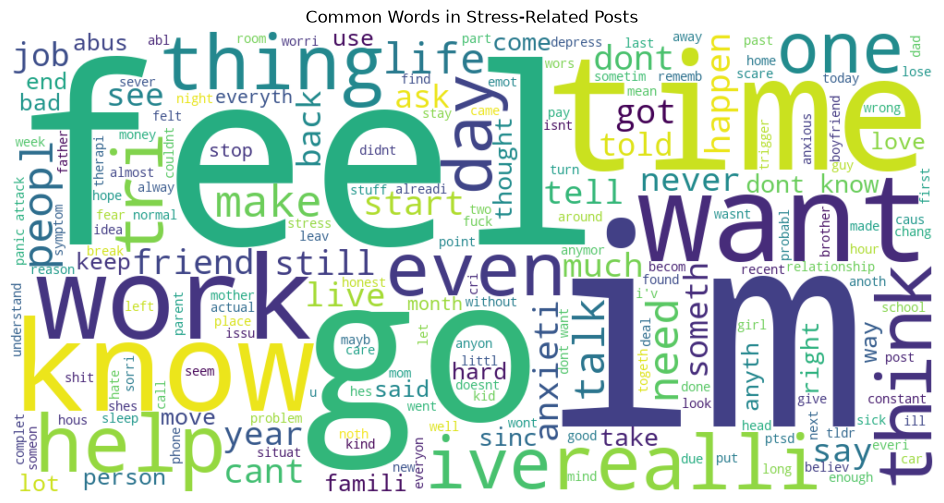

In [25]:
stress_text = " ".join(
    data[data["label"] == "Stress"]["text"]
)

stress_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(stress_text)

plt.figure(figsize=(12, 6))
plt.imshow(stress_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Stress-Related Posts")
plt.show()

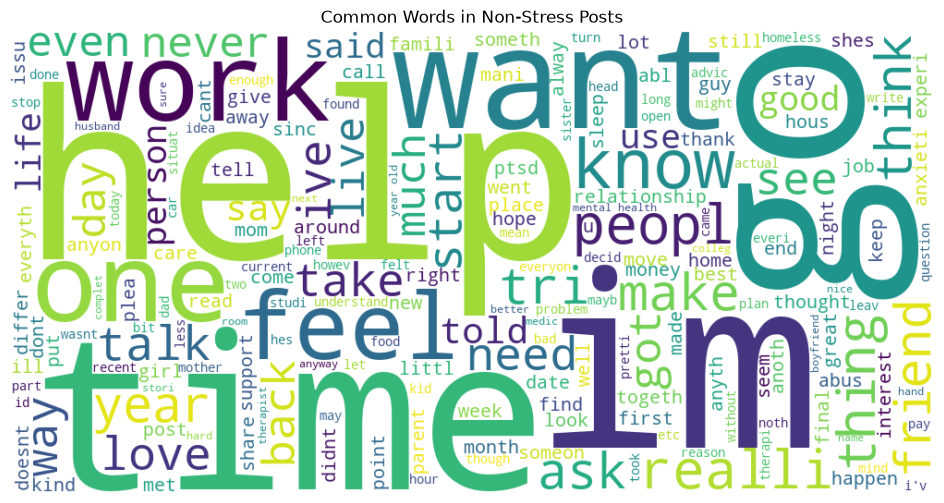

In [26]:
no_stress_text = " ".join(
    data[data["label"] == "No Stress"]["text"]
)

no_stress_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(no_stress_text)

plt.figure(figsize=(12, 6))
plt.imshow(no_stress_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Non-Stress Posts")
plt.show()

## 6. Train/Test Split and TF-IDF

The dataset is divided into training and testing sets using an 80:20 split. TF-IDF is then used to convert the cleaned text into numerical features.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    data["text"],
    data["label"],
    test_size=0.2,
    random_state=42,
    stratify=data["label"]
)

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

## 7. Model Training

### 7.1 Bernoulli Naive Bayes

In [28]:
from sklearn.naive_bayes import BernoulliNB

nb_model = BernoulliNB()

nb_model.fit(X_train, y_train)

nb_prediction = nb_model.predict(X_test)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Naive Bayes Performance")
print("-" * 30)

print("Accuracy :", accuracy_score(y_test, nb_prediction))
print("Precision:", precision_score(y_test, nb_prediction, pos_label="Stress"))
print("Recall   :", recall_score(y_test, nb_prediction, pos_label="Stress"))
print("F1 Score :", f1_score(y_test, nb_prediction, pos_label="Stress"))

print("\nClassification Report:")
print(classification_report(y_test, nb_prediction))

Naive Bayes Performance
------------------------------
Accuracy : 0.7464788732394366
Precision: 0.727810650887574
Recall   : 0.825503355704698
F1 Score : 0.7735849056603774

Classification Report:
              precision    recall  f1-score   support

   No Stress       0.77      0.66      0.71       270
      Stress       0.73      0.83      0.77       298

    accuracy                           0.75       568
   macro avg       0.75      0.74      0.74       568
weighted avg       0.75      0.75      0.74       568



### 7.2 Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [31]:
print("Logistic Regression Performance")
print("-" * 35)

print("Accuracy :", accuracy_score(y_test, lr_prediction))
print("Precision:", precision_score(y_test, lr_prediction, pos_label="Stress"))
print("Recall   :", recall_score(y_test, lr_prediction, pos_label="Stress"))
print("F1 Score :", f1_score(y_test, lr_prediction, pos_label="Stress"))

print("\nClassification Report:")
print(classification_report(y_test, lr_prediction))

Logistic Regression Performance
-----------------------------------
Accuracy : 0.7605633802816901
Precision: 0.7718120805369127
Recall   : 0.7718120805369127
F1 Score : 0.7718120805369127

Classification Report:
              precision    recall  f1-score   support

   No Stress       0.75      0.75      0.75       270
      Stress       0.77      0.77      0.77       298

    accuracy                           0.76       568
   macro avg       0.76      0.76      0.76       568
weighted avg       0.76      0.76      0.76       568



### 7.3 Linear SVM

In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_prediction = svm_model.predict(X_test)

print("Linear SVM model trained successfully!")

Linear SVM model trained successfully!


In [33]:
print("Linear SVM Performance")
print("-" * 30)

print("Accuracy :", accuracy_score(y_test, svm_prediction))
print("Precision:", precision_score(y_test, svm_prediction, pos_label="Stress"))
print("Recall   :", recall_score(y_test, svm_prediction, pos_label="Stress"))
print("F1 Score :", f1_score(y_test, svm_prediction, pos_label="Stress"))

print("\nClassification Report:")
print(classification_report(y_test, svm_prediction))

Linear SVM Performance
------------------------------
Accuracy : 0.7411971830985915
Precision: 0.7508305647840532
Recall   : 0.7583892617449665
F1 Score : 0.7545909849749582

Classification Report:
              precision    recall  f1-score   support

   No Stress       0.73      0.72      0.73       270
      Stress       0.75      0.76      0.75       298

    accuracy                           0.74       568
   macro avg       0.74      0.74      0.74       568
weighted avg       0.74      0.74      0.74       568



## 8. Model Evaluation

In [34]:
results = pd.DataFrame({
    "Model": [
        "Bernoulli Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_prediction),
        accuracy_score(y_test, lr_prediction),
        accuracy_score(y_test, svm_prediction)
    ],
    "Precision": [
        precision_score(y_test, nb_prediction, pos_label="Stress"),
        precision_score(y_test, lr_prediction, pos_label="Stress"),
        precision_score(y_test, svm_prediction, pos_label="Stress")
    ],
    "Recall": [
        recall_score(y_test, nb_prediction, pos_label="Stress"),
        recall_score(y_test, lr_prediction, pos_label="Stress"),
        recall_score(y_test, svm_prediction, pos_label="Stress")
    ],
    "F1 Score": [
        f1_score(y_test, nb_prediction, pos_label="Stress"),
        f1_score(y_test, lr_prediction, pos_label="Stress"),
        f1_score(y_test, svm_prediction, pos_label="Stress")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Bernoulli Naive Bayes,0.746479,0.727811,0.825503,0.773585
1,Logistic Regression,0.760563,0.771812,0.771812,0.771812
2,Linear SVM,0.741197,0.750831,0.758389,0.754591


### Model Comparison

Three classification algorithms were evaluated using accuracy, precision, recall, and F1-score.

Logistic Regression achieved the highest overall accuracy of approximately 76%, while Bernoulli Naive Bayes achieved slightly higher recall for the Stress class.

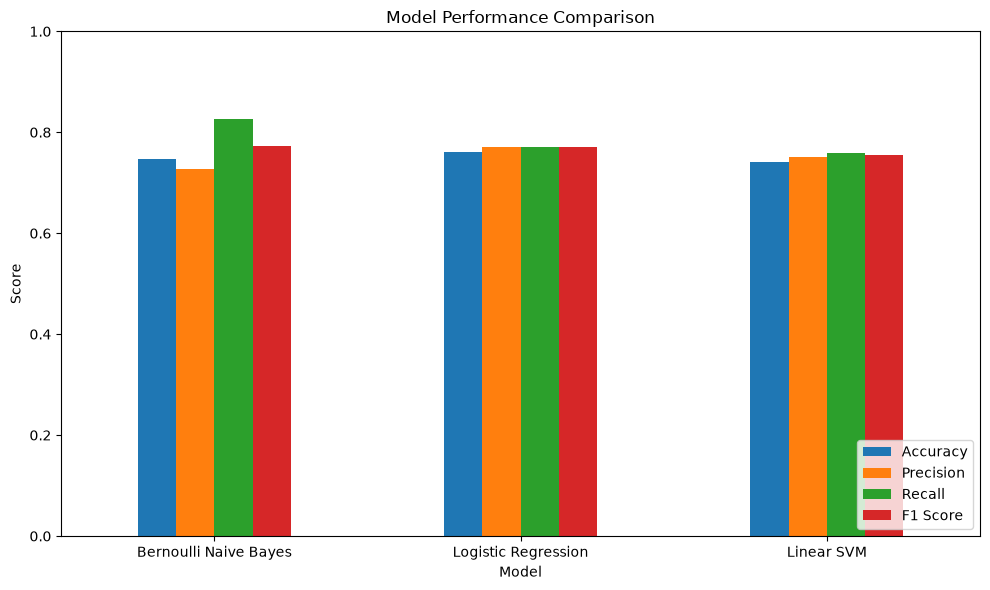

In [35]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 9. Confusion Matrix

The confusion matrix shows the correct and incorrect predictions made by the selected Logistic Regression model.

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_prediction)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[202  68]
 [ 68 230]]


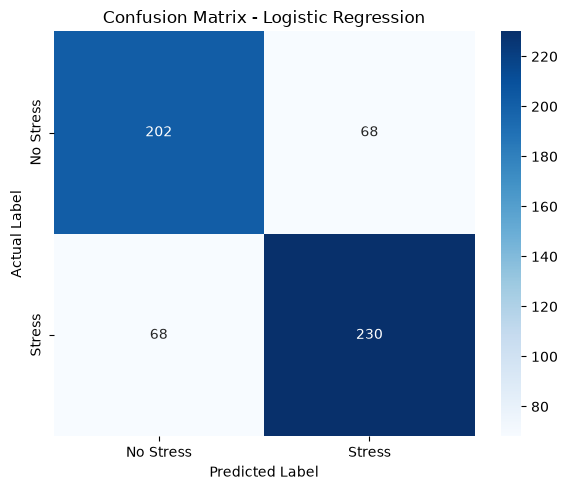

In [37]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stress", "Stress"],
    yticklabels=["No Stress", "Stress"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

## 10. Stress Prediction on New Text

The trained model can be used to classify new user-provided text as either Stress or No Stress.

In [38]:
def predict_stress(text):
    cleaned_text = clean_text(text)
    text_vector = vectorizer.transform([cleaned_text])
    prediction = lr_model.predict(text_vector)[0]

    return prediction

In [42]:
user_text = input("Enter a text: ")

prediction = predict_stress(user_text)

print("Prediction:", prediction)

Prediction: No Stress


## 11. Save Trained Model

The trained Logistic Regression model and TF-IDF vectorizer are saved using Joblib so they can be reused without retraining.

In [43]:
import joblib

joblib.dump(lr_model, "models/stress_model.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
